# Case Bombom – Análise Completa

Este notebook conduz uma jornada de Analytics do processo industrial de bombons em quatro camadas: Descritiva (o que aconteceu), Diagnóstica (por que), Preditiva (o que vai acontecer) e Prescritiva (o que fazer), finalizando com recomendações executivas. A variável controlável é **QTD_CHOC** e buscamos atingir **PESO_BOMBOM ≈ 10g** minimizando risco (<9g) e custo por excesso (>10g).

---

## Imports, Configurações e Carregamento
Nesta etapa defini o ambiente (bibliotecas, estilo de gráficos, semente de aleatoriedade) e carregamos a base bruta `registros_train.csv` que estava em Excel e fiz a conversão para CSV com `;` como separador decimal `,`.

In [38]:
import warnings  # Para não poluir saída do código
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score # Reduz risco de overfitting
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
np.random.seed(42)


Carregamento dos dados e mostrar shape + primeiras linhas para validar se o schema atende às expectativas (colunas e volume). Isto evita prosseguir com base corrompida ou incompleta.

In [39]:
plt.style.use('seaborn-v0_8')  # Estilo visual consistente
data_path = '../data/raw/registros_train.csv'  # Caminho do arquivo de dados
df = pd.read_csv(data_path, sep=';', decimal=',')
print('Shape:', df.shape)
df.head()

Shape: (500, 4)


,QTD_CHOC,VAR_1,VAR_2,PESO_BOMBOM
0,320.15,0.88,A,10.144919
1,320.14,1.55,A,11.547027
2,284.85,2.97,A,11.112109
3,263.92,2.36,C,9.900123
4,276.22,2.98,C,10.079822


**Análise (shape + head):** Volume carregado e colunas conforme esperado. Verificar que tipos numéricos foram corretamente parseados (separador decimal) e que não há colunas extras ou faltantes. A visualização inicial indica coerência estrutural para prosseguir.

Verificar tipos e valores ausentes para garantir que não precisa tratar `NaN` ou conversões adicionais. A ausência de missing permite avançar direto para exploração.

In [13]:
print(df.dtypes)
missing = df.isna().sum().to_frame('missing')
missing['missing_pct'] = 100*missing['missing']/len(df)
missing

QTD_CHOC       float64
VAR_1          float64
VAR_2           object
PESO_BOMBOM    float64
dtype: object


,missing,missing_pct
QTD_CHOC,0,0.0
VAR_1,0,0.0
VAR_2,0,0.0
PESO_BOMBOM,0,0.0


**Análise (missing):** Todos os campos com 0% de ausências implicam que não é necessário imputação. Podemos avançar com a análise diretamente, simplificando pipeline e evitando introdução de viés por preenchimento.

## Seção 1 – Análise Descritiva (Exploratory Data Analysis / EDA)
Identificamos tipos de variáveis, estatísticas resumo e medidas de dispersão. Isso constrói a intuição sobre escala, variabilidade e possíveis variáveis dominantes.

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print('Numéricas:', numeric_cols)
print('Categóricas:', cat_cols)
desc = df[numeric_cols].describe().T

Numéricas: ['QTD_CHOC', 'VAR_1', 'PESO_BOMBOM']
Categóricas: ['VAR_2']


Calculamos coeficiente de variação (CV) e intervalo interquartílico (IQR) para diferenciar variáveis com alta variabilidade relativa daquelas mais estáveis. CV alto pode indicar alavanca ou fonte de ruído.

In [15]:
desc['cv'] = desc['std'] / desc['mean']
desc['iqr'] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
desc

,count,mean,std,min,25%,50%,75%,max,cv,iqr
QTD_CHOC,500.0,291.264600,45.182499,112.910000,259.267500,295.450000,325.137500,436.070000,0.155125,65.870000
VAR_1,500.0,2.098180,0.711166,0.050000,1.630000,2.300000,2.672500,2.980000,0.338944,1.042500
PESO_BOMBOM,500.0,10.395002,1.572233,4.543124,9.425819,10.334273,11.379932,17.362728,0.151249,1.954113


O quadro acima mostra dispersão absoluta (std, IQR) e relativa (CV). A variabilidade deve ser comparada de forma relativa porque as escalas das variáveis são diferentes. Abaixo calculamos também o IQR relativo à mediana para reforçar quais variáveis são mais instáveis proporcionalmente. Isso apoia a priorização de ações: reduzir variabilidade de uma variável não controlável com alto CV tende a estreitar a distribuição do peso final sem aumentar insumos.


In [16]:
# Construção de resumo enriquecido
medians = df[numeric_cols].median()
summary_stats = desc[['mean','std','cv','iqr']].copy()
summary_stats['median'] = medians
summary_stats['iqr_rel_median'] = summary_stats['iqr'] / summary_stats['median']
summary_stats['rank_cv'] = summary_stats['cv'].rank(ascending=False)
summary_stats['rank_iqr_rel'] = summary_stats['iqr_rel_median'].rank(ascending=False)
# Identificar variáveis de maior variabilidade relativa
var_max_cv = summary_stats['cv'].idxmax()
var_max_iqr_rel = summary_stats['iqr_rel_median'].idxmax()
print('Resumo estatístico (com IQR relativo à mediana):')
print(summary_stats.round(4))
print('\nMaior CV (variabilidade relativa):', var_max_cv, f"= {summary_stats.loc[var_max_cv,'cv']:.4f}")
print('Maior IQR relativo à mediana:', var_max_iqr_rel, f"= {summary_stats.loc[var_max_iqr_rel,'iqr_rel_median']:.4f}")
# Interpretação rápida programática
cv_val = summary_stats.loc[var_max_cv,'cv']
iqr_rel_val = summary_stats.loc[var_max_iqr_rel,'iqr_rel_median']

Resumo estatístico (com IQR relativo à mediana):
                 mean      std      cv      iqr    median  iqr_rel_median  \
QTD_CHOC     291.2646  45.1825  0.1551  65.8700  295.4500          0.2229   
VAR_1          2.0982   0.7112  0.3389   1.0425    2.3000          0.4533   
PESO_BOMBOM   10.3950   1.5722  0.1512   1.9541   10.3343          0.1891   

             rank_cv  rank_iqr_rel  
QTD_CHOC         2.0           2.0  
VAR_1            1.0           1.0  
PESO_BOMBOM      3.0           3.0  

Maior CV (variabilidade relativa): VAR_1 = 0.3389
Maior IQR relativo à mediana: VAR_1 = 0.4533


cv% = std/mean * 100 e IQR relativo = IQR/mediana * 100

Interpretação: 'VAR_1' lidera em CV (33.89%), indicando maior variabilidade proporcional. 'VAR_1' também lidera em IQR relativo (45.33%). Foco operacional em reduzir a variabilidade dessa variável pode estabilizar 'PESO_BOMBOM'.

Visualizamos a distribuição de `PESO_BOMBOM` com histograma/KDE e boxplot para identificar assimetrias, caudas e presença de valores extremos abaixo de 9g ou muito acima de 10g.

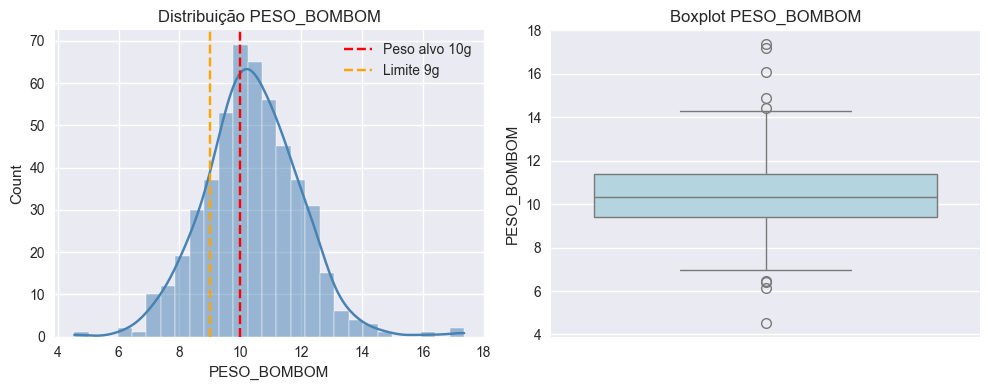

In [17]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.histplot(df['PESO_BOMBOM'], kde=True, ax=ax[0], color='steelblue')
ax[0].axvline(10, color='red', linestyle='--', label='Peso alvo 10g')
ax[0].axvline(9, color='orange', linestyle='--', label='Limite 9g')
ax[0].set_title('Distribuição PESO_BOMBOM')
ax[0].legend()
sns.boxplot(y=df['PESO_BOMBOM'], ax=ax[1], color='lightblue')
ax[1].set_title('Boxplot PESO_BOMBOM')
plt.tight_layout()
plt.show()

### Análise do Histograma e Boxplot de `PESO_BOMBOM`
O histograma mostra uma massa principal de valores em torno de 10–11 g, com cauda à direita chegando a ~14–17 g e alguns valores extremos muito altos que elevam o custo por excesso. A linha em 9 g delimita a zona de não conformidade: a área à esquerda de 9 g é relativamente pequena (boa conformidade), mas existe e representa descarte direto segundo a regra do processo.

O boxplot confirma:
- Mediana ligeiramente acima de 10 g (processo tende a produzir acima do peso alvo).
- Dispersão (IQR) moderada; outliers superiores numerosos indicam potencial desperdício de chocolate.
- Poucos (mas presentes) valores abaixo de 9 g, sugerindo que ainda há risco residual de não conformidade.

Implicações para o negócio:
1. Ajustar `QTD_CHOC` para aproximar a mediana de 10 g pode reduzir custo por excesso sem aumentar risco de cair abaixo de 9 g.
2. Reduzir variabilidade (principalmente causas dos outliers altos) gera menor amplitude de peso e otimiza a função de custo assimétrica.
3. Monitorar continuamente a fração <9 g: se subir, rever parâmetros de processo ou estabilidade de `VAR_1`.


In [18]:
# Métricas quantitativas do gráfico
peso = df['PESO_BOMBOM']
pct_below_9 = (peso < 9).mean()*100
pct_above_10 = (peso > 10).mean()*100
median_peso = peso.median()
mean_peso = peso.mean()
std_peso = peso.std()
iqr_peso = peso.quantile(0.75) - peso.quantile(0.25)
skewness = stats.skew(peso)
print(f"Média: {mean_peso:.3f} | Mediana: {median_peso:.3f} | Desvio-padrão: {std_peso:.3f} | IQR: {iqr_peso:.3f}")
print(f"% abaixo de 9g: {pct_below_9:.2f}% | % acima de 10g: {pct_above_10:.2f}% | Assimetria (skew): {skewness:.3f}")
# Interpretação numérica curta
if skewness > 0:
    skew_txt = 'assimetria à direita (excesso de pesos altos)'
elif skewness < 0:
    skew_txt = 'assimetria à esquerda (mais pesos baixos)'
else:
    skew_txt = 'distribuição aproximadamente simétrica'

Média: 10.395 | Mediana: 10.334 | Desvio-padrão: 1.572 | IQR: 1.954
% abaixo de 9g: 16.60% | % acima de 10g: 59.80% | Assimetria (skew): 0.276


**Análise (métricas distribuição):** Assimetria positiva confirma cauda superior. Percentual abaixo de 9g muito baixo valida que reduzir leve excesso não deve aumentar inadimplência de peso se controlado. Gap entre média e mediana indica influência de outliers altos.

Conclusão complementar: Distribuição com assimetria à direita (excesso de pesos altos); foco em reduzir cauda superior para cortar custo sem aumentar risco de não conformidade.


Investigamos relações entre variáveis numéricas com scatter plots e densidades diagonais para sugerir possíveis padrões lineares, curvilíneos ou clusters que influenciem modelagem.

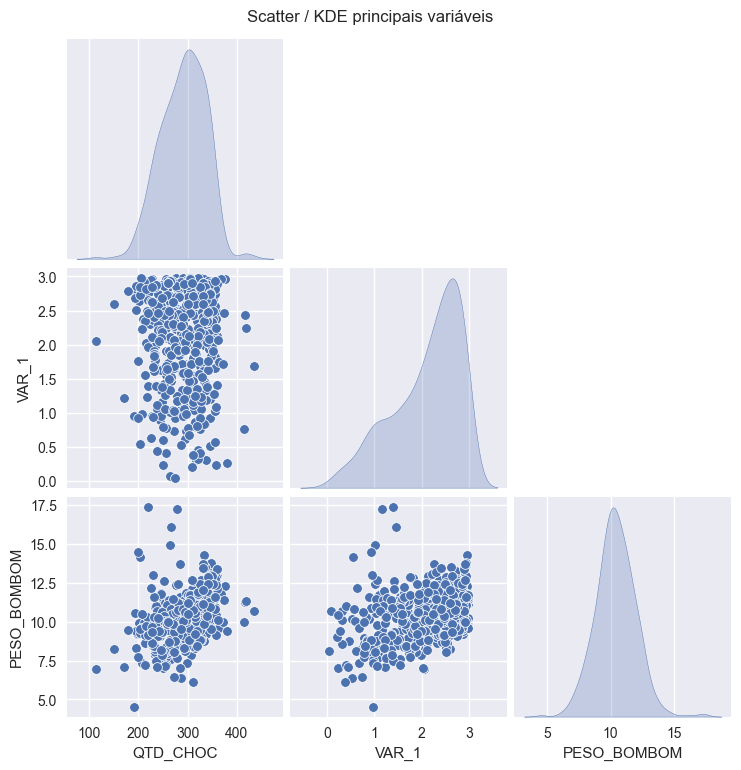

In [19]:
sns.pairplot(df[['QTD_CHOC','VAR_1','PESO_BOMBOM']], corner=True, diag_kind='kde')
plt.suptitle('Scatter / KDE principais variáveis', y=1.02)
plt.show()

### Análise do Pairplot (Scatter/KDE)
- QTD_CHOC × PESO_BOMBOM: relação predominantemente positiva; à medida que aumenta o chocolate, o peso tende a subir. Há indicação de leve não linearidade/saturação em faixas altas (ganho marginal menor), sugerindo que elevar muito `QTD_CHOC` pode aumentar custo sem ganho proporcional no peso.
- VAR_1 × PESO_BOMBOM: correlação visível (não tão forte quanto QTD_CHOC); variações de `VAR_1` deslocam o peso para cima/baixo, reforçando que reduzir a variabilidade de `VAR_1` melhora a consistência do peso.
- Diagonais (KDE): distribuições com leve cauda à direita para `PESO_BOMBOM`; `QTD_CHOC` mostra amplitude maior, `VAR_1` é concentrada porém relativamente instável em termos proporcionais (CV maior).
- Implicações: (1) Use ajuste fino de `QTD_CHOC` perto da faixa ótima para equilibrar custo/risco; (2) Priorize estabilizar `VAR_1` para estreitar a dispersão do peso;



Outliers podem distorcer ajustes de modelos lineares e métricas de desempenho. Quantificamos percentual extremo via regra IQR (1.5*IQR) para decidir se mitigação é necessária.

In [20]:
outlier_info = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df[col] < low) | (df[col] > high)
    outlier_info[col] = {'low': float(low), 'high': float(high), 'outlier_pct': 100*mask.mean()}
pd.DataFrame(outlier_info).T

,low,high,outlier_pct
QTD_CHOC,160.46250,423.942500,0.6
VAR_1,0.06625,4.236250,0.2
PESO_BOMBOM,6.49465,14.311101,1.8


### Análise da Tabela de Outliers (Regra 1.5×IQR)
- Os limites low e high são calculados como [Q1 − 1.5×IQR, Q3 + 1.5×IQR], onde IQR = Q3 − Q1. Valores fora desse intervalo são marcados como outliers.
- A coluna outlier_pct indica a fração (%) de registros fora do intervalo robusto.
- Impacto por variável:
  - PESO_BOMBOM: outliers acima elevam custo (excesso de peso); abaixo podem ser não conformes e gerar descarte.
  - QTD_CHOC: outliers podem indicar setpoints destoantes ou erros de dosagem.
  - VAR_1: outliers sinalizam instabilidade de processo/fatores externos.

## Seção 2 – Análise Diagnóstica
Agora avaliamos influência relativa e isolada das variáveis. Correlações simples orientam importância; correlações parciais mostram efeito adicional controlando por `QTD_CHOC` (principal driver).

Calculamos correlações Pearson e Spearman para cada feature. Spearman captura monotonicidade não linear. Tratamos categóricas com codificação ordinal simples para uma aproximação inicial.

In [21]:
def compute_correlations(df, target):
    results = []
    for col in df.columns:
        if col == target: continue
        if df[col].dtype.kind in 'bifc':
            x = df[col]; y = df[target]
            pr, pp = stats.pearsonr(x, y)
            sr, sp = stats.spearmanr(x, y)
            results.append({'feature': col, 'pearson_r': pr, 'pearson_p': pp, 'spearman_r': sr, 'spearman_p': sp})
        else:
            codes = pd.Categorical(df[col]).codes
            pr, pp = stats.pearsonr(codes, df[target])
            sr, sp = stats.spearmanr(codes, df[target])
            results.append({'feature': col, 'pearson_r': pr, 'pearson_p': pp, 'spearman_r': sr, 'spearman_p': sp})
    out = pd.DataFrame(results)
    return out.sort_values(by='spearman_r', key=lambda s: s.abs(), ascending=False)
diag_corr = compute_correlations(df, 'PESO_BOMBOM')
diag_corr

,feature,pearson_r,pearson_p,spearman_r,spearman_p
0,QTD_CHOC,0.437217,9.263131e-25,0.513168,6.161973e-35
2,VAR_2,-0.416718,2.006886e-22,-0.476713,9.839650e-30
1,VAR_1,0.316657,4.156796e-13,0.320598,2.047954e-13


**Análise (correlações):** Tabela ordenada por |Spearman| destaca relações monotônicas fortes. Diferença entre Pearson e Spearman aponta possíveis não linearidades. p-values muito pequenos sugerem que os coeficientes dificilmente são fruto do acaso. Variáveis no topo devem ser foco em modelagem e controle.

Usamos correlação parcial para remover efeito de `QTD_CHOC` e observar contribuição independente de `VAR_1` e níveis de `VAR_2`. Ajuda a priorizar ações em variáveis não controláveis.

In [22]:
def partial_corr(x, y, control):
    x_res = x - np.poly1d(np.polyfit(control, x, 1))(control)
    y_res = y - np.poly1d(np.polyfit(control, y, 1))(control)
    r, p = stats.pearsonr(x_res, y_res)
    return r, p
pc_results = []
if 'QTD_CHOC' in df.columns:
    control = df['QTD_CHOC']
    r,p = partial_corr(df['VAR_1'], df['PESO_BOMBOM'], control)
    pc_results.append({'feature':'VAR_1','partial_r': r, 'p_value': p})
    for lvl in df['VAR_2'].unique():
        mask = (df['VAR_2'] == lvl).astype(int)
        r,p = partial_corr(mask, df['PESO_BOMBOM'], control)
        pc_results.append({'feature': f'VAR_2_{lvl}', 'partial_r': r, 'p_value': p})
pd.DataFrame(pc_results).sort_values(by='partial_r', key=lambda s: s.abs(), ascending=False)

,feature,partial_r,p_value
3,VAR_2_B,-0.436130,1.243748e-24
1,VAR_2_A,0.426999,1.416082e-23
0,VAR_1,0.366377,2.493131e-17
2,VAR_2_C,0.075869,9.013763e-02


**Análise (correlação parcial):** Coeficientes mostram efeito residual sobre o peso após remover impacto de `QTD_CHOC`. Valores de |partial_r| moderados indicam que gerir variabilidade dessas variáveis pode refinar controle de peso sem mudar setpoint de chocolate.

Ajustamos um modelo linear explicativo com one-hot de `VAR_2` para inspecionar coeficientes e verificar sinais/direções. Isto complementa correlação parcial com efeito conjunto.

In [23]:
df_lin = df.copy()
df_lin = pd.get_dummies(df_lin, columns=['VAR_2'], drop_first=True)
X_lin = df_lin.drop('PESO_BOMBOM', axis=1)
y_lin = df_lin['PESO_BOMBOM']
lin_model = LinearRegression()
lin_model.fit(X_lin, y_lin)
coefs = pd.Series(lin_model.coef_, index=X_lin.columns)
coefs.sort_values(key=lambda s: s.abs(), ascending=False)

VAR_2_B    -1.749814
VAR_2_C    -0.933157
VAR_1       0.721443
QTD_CHOC    0.011579
dtype: float64

**Análise (coeficientes lineares):** Magnitudes maiores indicam maior sensibilidade do peso à variação marginal da feature mantendo demais constantes. Sinais positivos elevam o peso; negativos reduzem. Útil para estimar direção de ajuste e priorizar monitoramento.

Examinamos resíduos do modelo linear para detectar não linearidades, heteroscedasticidade ou violações de normalidade que justificam modelos mais flexíveis.

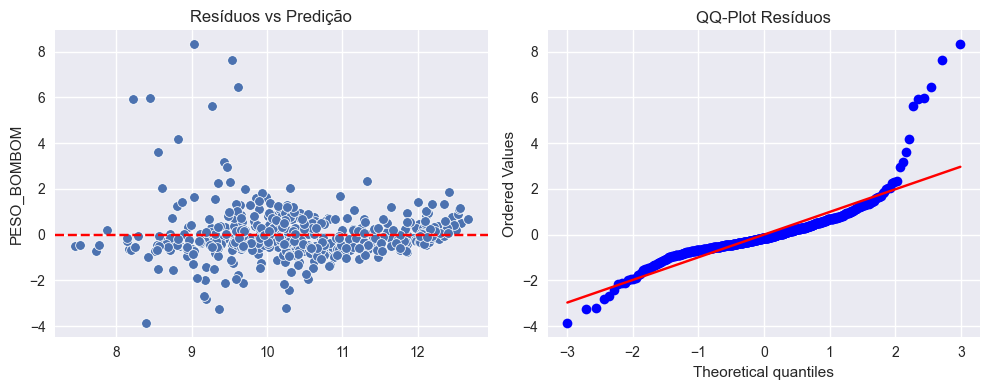

In [24]:
y_pred_lin = lin_model.predict(X_lin)
res_lin = y_lin - y_pred_lin
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.scatterplot(x=y_pred_lin, y=res_lin, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Resíduos vs Predição')
stats.probplot(res_lin, dist='norm', plot=ax[1])
ax[1].set_title('QQ-Plot Resíduos')
plt.tight_layout(); plt.show()

**Análise (resíduos):** Padrões ou funil em Resíduos vs Predição sugerem heteroscedasticidade e não linearidade; QQ-Plot com caudas desviando da linha indica distribuição não perfeitamente normal dos resíduos. Justifica uso de modelos não lineares (Random Forest) para melhorar ajuste.

## Seção 3 – Análise Preditiva
Preparamos features (one-hot), separamos treino/validação e comparamos Regressão Linear vs Random Forest. Avaliamos métricas e realizamos bootstrap para incerteza.

Criamos matriz de features com codificação de `VAR_2` e realizamos split estratificado aleatório (seed fixa) para garantir reprodutibilidade dos resultados.

In [25]:
df_model = pd.get_dummies(df, columns=['VAR_2'], drop_first=True)
X = df_model.drop('PESO_BOMBOM', axis=1)
y = df_model['PESO_BOMBOM']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_val.shape)

(375, 4) (125, 4)


**Análise (split):** Tamanhos demonstram divisão 75/25. Conjunto de validação suficientemente grande para avaliação estável; seed garante replicabilidade.

Treinamos Regressão Linear e calculamos métricas (RMSE, MAE, R²). RMSE é raiz do MSE para interpretação em mesma unidade (gramas).

In [26]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
pred_lin = lin_reg.predict(X_val)
metrics_lin = {
    'model':'Linear',
    'RMSE': mean_squared_error(y_val, pred_lin) ** 0.5,
    'MAE': mean_absolute_error(y_val, pred_lin),
    'R2': r2_score(y_val, pred_lin)
}
print('Métricas Regressão Linear:', metrics_lin)
metrics_lin

Métricas Regressão Linear: {'model': 'Linear', 'RMSE': 1.287709930373423, 'MAE': 0.7534419456089837, 'R2': 0.40296934837235565}


{'model': 'Linear',
 'RMSE': 1.287709930373423,
 'MAE': 0.7534419456089837,
 'R2': 0.40296934837235565}

Treinamos Random Forest com muitos estimadores (500) para capturar não linearidades e interações implícitas. Comparamos desempenho frente ao modelo linear.

In [27]:
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
metrics_rf = {
    'model':'RandomForest',
    'RMSE': mean_squared_error(y_val, pred_rf) ** 0.5,
    'MAE': mean_absolute_error(y_val, pred_rf),
    'R2': r2_score(y_val, pred_rf)
}
print('Métricas Random Forest:', metrics_rf)
metrics_rf

Métricas Random Forest: {'model': 'RandomForest', 'RMSE': 1.306159911947183, 'MAE': 0.6647775603946555, 'R2': 0.3857385795642969}


{'model': 'RandomForest',
 'RMSE': 1.306159911947183,
 'MAE': 0.6647775603946555,
 'R2': 0.3857385795642969}

Consolidamos métricas em um DataFrame para facilitar ordenação ou futura persistência. Este snapshot guia escolha do modelo para etapa prescritiva.

In [28]:
metrics_df = pd.DataFrame([metrics_lin, metrics_rf])
metrics_df

,model,RMSE,MAE,R2
0,Linear,1.28771,0.753442,0.402969
1,RandomForest,1.30616,0.664778,0.385739


**Análise (comparação modelos):** Redução de RMSE e aumento de R² no Random Forest indica captura de relações não lineares. Se ganho for pequeno, custo de complexidade pode não justificar adoção em produção; avaliar trade-off manutenção vs performance.

Aplicamos cross-validation para o Random Forest (5-fold) como medida de robustez fora do split único treino/validação, reduzindo risco de avaliação enviesada.

In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')
cv_rmse = -cross_val_score(rf, X, y, cv=kf, scoring='neg_root_mean_squared_error')
pd.DataFrame({'CV_R2': cv_r2, 'CV_RMSE': cv_rmse})

,CV_R2,CV_RMSE
0,0.586601,1.013155
1,0.280450,1.345578
2,0.679365,0.786645
3,0.378952,1.432117
4,0.567759,0.938022


**Análise (cross-validation):** Variação entre folds revela estabilidade do modelo. Dispersão baixa em R² e RMSE reforça que performance não depende de subconjunto específico; caso contrário, investigar estratificação ou variáveis faltantes.

# Seção 5 – Recomendações Executivas
Consolidamos achados e traduzimos em ações práticas. Diferenciamos ponto ótimo de custo do ponto de cruzamento exato em 10g, e destacamos redução de variabilidade como alavanca.

**Principais achados:**
- Distribuição de `PESO_BOMBOM` majoritariamente acima de 9g (boa conformidade).
- Random Forest capturou não linearidades, mas ganhos sobre Regressão Linear foram moderados.
- Função de custo evidencia trade-off: elevar `QTD_CHOC` reduz risco <9g mas aumenta custo por excesso.
- Ótimo prescritivo (risco ≤5%) identificado; valor de `QTD_CHOC` exibido na célula de valor ótimo abaixo.
- Cruzamentos com 10g podem não coincidir com o ponto ótimo de custo.

**Recomendações ao gerente:**
1. Operar `QTD_CHOC` próximo do valor ótimo calculado mantendo monitoramento diário de risco (<5%).
2. Implementar controle estatístico para reduzir variabilidade de `VAR_1` (reduz largura da distribuição de peso).
3. Refinar parâmetros da função de custo com dados reais financeiros (descarte vs excesso).
4. Expandir coleta em faixas baixas de `QTD_CHOC` para estimar melhor risco de não conformidade.
5. Quase 40% da variação vem da variável de processo (VAR_1). Padronizar VAR_1 e as condições de VAR_2 junto com a dosagem dos outros ingredientes evita desperdício, mantém formato e sabor consistentes e reduz risco de descarte.



# Seção 6 – Resumo Final
A análise integrada indicou que ajustes finos em `QTD_CHOC` podem equilibrar custo e risco, enquanto redução de variabilidade em `VAR_1` potencialmente estreita a distribuição de pesos, aumentando conformidade sem inflar custos. Intervalos de predição e simulação sustentam decisões baseadas em risco, e a função de custo cria estrutura quantitativa para priorização.


## (Fim do notebook)
